
# Customer Segmentation Using pyspark

This project introduces the application of PySpark for customer segmentation, leveraging its parallel processing capabilities to analyze large-scale eCommerce datasets efficiently. By employing techniques such as RFM analysis, clustering, or classification, we aim to categorize customers based on their purchasing behaviors and characteristics. Through this segmentation process, businesses can gain valuable insights into customer preferences, enabling targeted marketing strategies, personalized experiences, and improved overall performance.

In [1]:
!pip install pyspark  #installing pyspark

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import sys
import math
from pyspark.sql import SparkSession
from pyspark.context import SparkContext
from pyspark.sql.functions import *
import pyspark.sql.functions as f
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import pyarrow


In [3]:
# Initializing Spark session

sc = SparkSession.builder.appName("Customer_Segmentation") \
.config ("spark.sql.shuffle.partitions", "16") \
.config("spark.driver.maxResultSize","4g") \
.config ("spark.sql.execution.arrow.enabled", "true") \
.config("spark.driver.memory", "4g") \
.config("spark.executor.cores", "4") \
.getOrCreate()

sc.sparkContext.setLogLevel("ERROR")

**Description of Dataset**


*   event_time: The timestamp of the purchase event.
*   event_type: The type of event (e.g., view, click, purchase).
* product_id: The unique identifier for the product.
*   category_id: The unique identifier for the category of the product.
*   category_code: The code representing the category of the product.
*   brand: The brand of the product.
*   price: The price of the product.
*   user_id: The unique identifier for the user making the purchase.
*   user_session: The unique identifier for the session during which the purchase was made.

## EDA and Data Preprocessing

In [4]:
# load dataset
df = pd.read_csv('kz1.csv')

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import TimestampType

spark_df = sc.createDataFrame(df)

# Removing " UTC" from 'event_time' column
spark_df = spark_df.withColumn("event_time", col("event_time").substr(1, 19))

# Converting 'event_time' column to TimestampType
spark_df = spark_df.withColumn("event_time", col("event_time").cast(TimestampType()))
spark_df.show()



+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+
|         event_time|           order_id|         product_id|         category_id|       category_code|  brand|  price|             user_id|
+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2.268105426648171...|  electronics.tablet|samsung| 162.01|1.515915625441993...|
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2.268105426648171...|  electronics.tablet|samsung| 162.01|1.515915625441993...|
|2020-04-24 14:37:43|2294444024058086220|2273948319057183658|2.268105430162997...|electronics.audio...| huawei|  77.52|1.515915625447879...|
|2020-04-24 14:37:43|2294444024058086220|2273948319057183658|2.268105430162997...|electronics.audio...| huawei|  77.52|1.515915625447879...|
|2020-04-24 1

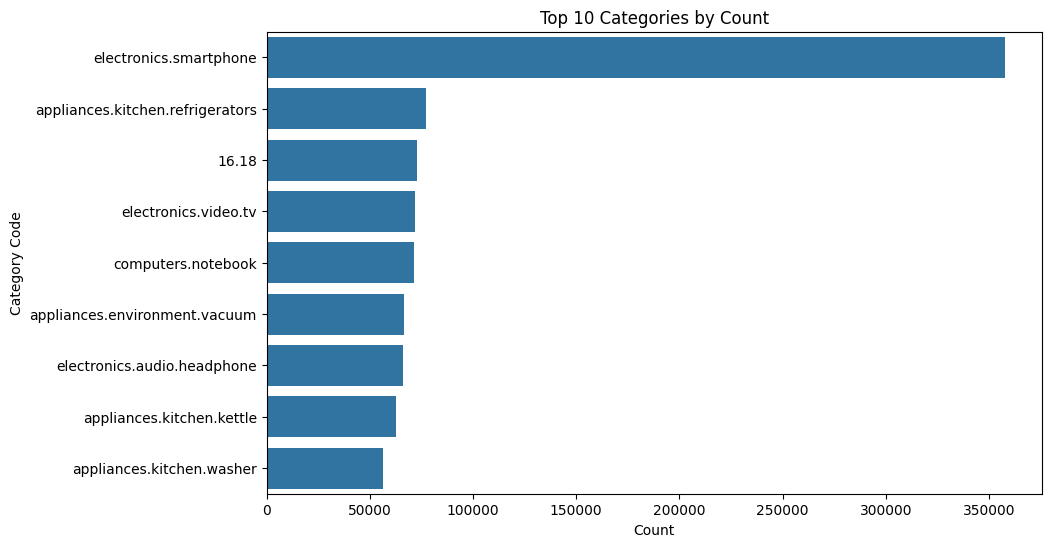

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Category-wise Analysis
category_counts = spark_df.groupBy("category_code").count().orderBy(col("count").desc()).limit(10).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=category_counts, x="count", y="category_code")
plt.title("Top 10 Categories by Count")
plt.xlabel("Count")
plt.ylabel("Category Code")
plt.show()




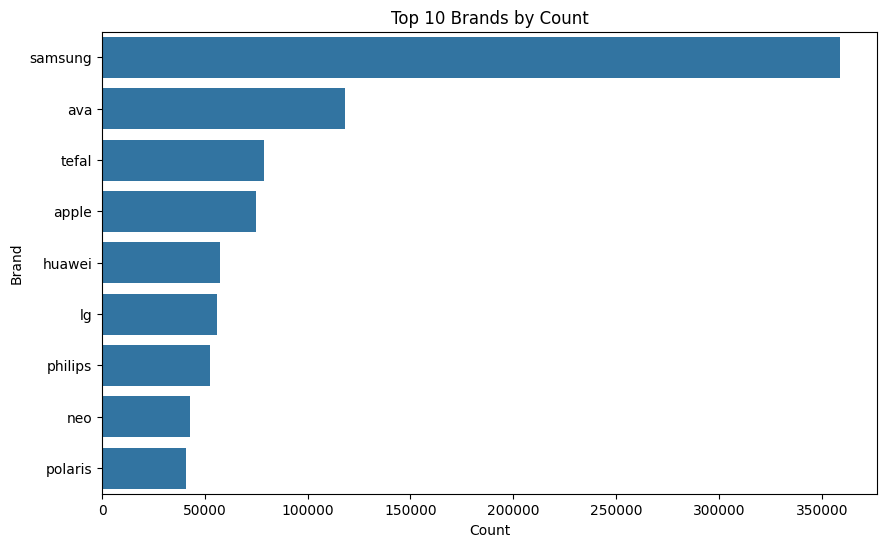

In [7]:
# Brand-wise Analysis
brand_counts = spark_df.groupBy("brand").count().orderBy(col("count").desc()).limit(10).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=brand_counts, x="count", y="brand")
plt.title("Top 10 Brands by Count")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

<Figure size 1000x600 with 0 Axes>

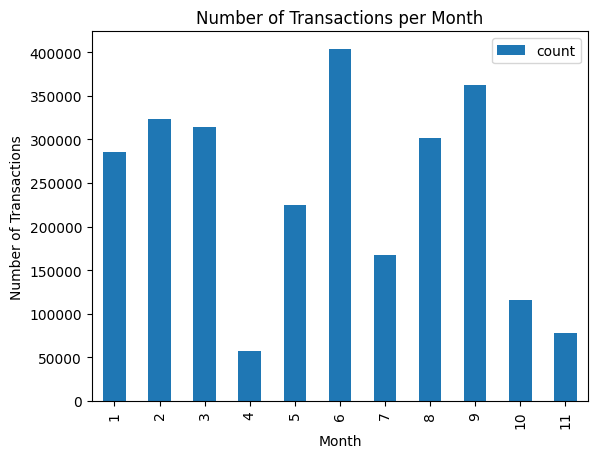

In [8]:
# User Behavior Over Time
spark_df = spark_df.withColumn("month", F.month("event_time"))

# Plot number of transactions per month
transaction_counts = spark_df.groupBy("month").count().orderBy("month").toPandas()

plt.figure(figsize=(10, 6))
transaction_counts.plot(kind="bar", x="month", y="count")
plt.title("Number of Transactions per Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

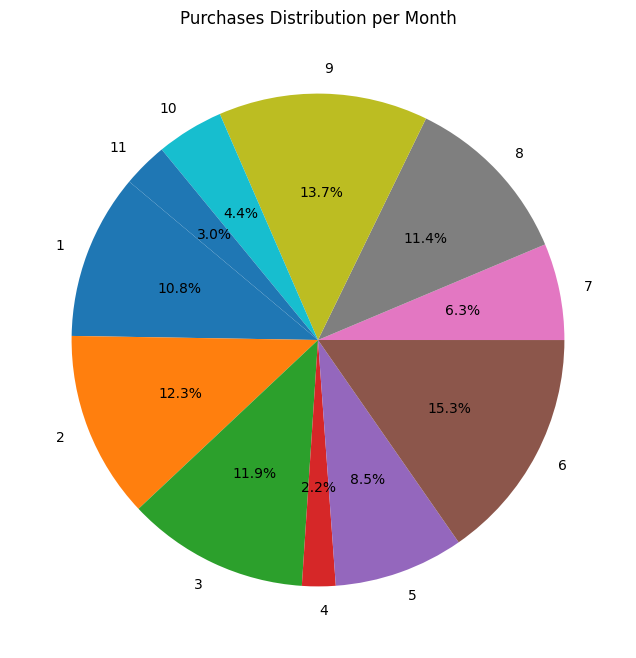

In [9]:
# Distribution of Purchases per Month
monthly_counts = spark_df.groupBy("month").count().orderBy("month").toPandas()

plt.figure(figsize=(8, 8))
plt.pie(monthly_counts["count"], labels=monthly_counts["month"], autopct='%1.1f%%', startangle=140)
plt.title("Purchases Distribution per Month")
plt.show()

In [10]:
numeric_cols = [col_name for col_name, dtype in spark_df.dtypes if dtype != "timestamp" and dtype != "string"]

# Calculating correlation matrix
corr_matrix = spark_df.select([corr(col1, col2).alias(f"corr_{col1}_{col2}") for col1 in numeric_cols for col2 in numeric_cols])
corr_matrix.show()

+----------------------+------------------------+-------------------------+-------------------+---------------------+-------------------+------------------------+--------------------------+---------------------------+---------------------+-----------------------+---------------------+-------------------------+---------------------------+----------------------------+----------------------+------------------------+----------------------+-------------------+---------------------+----------------------+----------------+--------------------+-------------------+---------------------+-----------------------+------------------------+--------------------+--------------------+-------------------+-------------------+---------------------+----------------------+-------------------+-------------------+----------------+
|corr_order_id_order_id|corr_order_id_product_id|corr_order_id_category_id|corr_order_id_price|corr_order_id_user_id|corr_order_id_month|corr_product_id_order_id|corr_product_id_prod

In [11]:
# Calculating percentage of missing values in PySpark DataFrame
missing_percentage = spark_df.select([(f.count(f.when(f.col(c).isNull(), c)) / f.count(c)).alias(c) for c in spark_df.columns])
missing_percentage.show()


+----------+--------+----------+-------------------+-------------------+-------------------+-------------------+-----------------+-----+
|event_time|order_id|product_id|        category_id|      category_code|              brand|              price|          user_id|month|
+----------+--------+----------+-------------------+-------------------+-------------------+-------------------+-----------------+-----+
|       0.0|     0.0|       0.0|0.19620297724302735|0.30287253026365457|0.23783839933518713|0.19620297724302735|3.667964741061632|  0.0|
+----------+--------+----------+-------------------+-------------------+-------------------+-------------------+-----------------+-----+



In [12]:
# Find the minimum and maximum dates in the PySpark DataFrame
min_max_dates = spark_df.select(f.min("event_time").alias("min_event_time"), f.max("event_time").alias("max_event_time"))
min_max_dates.show()


+-------------------+-------------------+
|     min_event_time|     max_event_time|
+-------------------+-------------------+
|1970-01-01 00:33:40|2020-11-21 10:10:30|
+-------------------+-------------------+



In [13]:
from pyspark.sql.functions import year

# Extracting year from 'event_time' column
spark_df = spark_df.withColumn("year", year("event_time"))

# Group by 'year' and count occurrences
year_counts = spark_df.groupBy("year").count()

year_counts.show()


+----+-------+
|year|  count|
+----+-------+
|2020|2613890|
|1970|  19631|
+----+-------+



In [14]:
from pyspark.sql.functions import year

# Filter out rows with the year 1970
spark_df = spark_df.filter(year("event_time") != 1970)
spark_df.show()


+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+-----+----+
|         event_time|           order_id|         product_id|         category_id|       category_code|  brand|  price|             user_id|month|year|
+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+-----+----+
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2.268105426648171...|  electronics.tablet|samsung| 162.01|1.515915625441993...|    4|2020|
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2.268105426648171...|  electronics.tablet|samsung| 162.01|1.515915625441993...|    4|2020|
|2020-04-24 14:37:43|2294444024058086220|2273948319057183658|2.268105430162997...|electronics.audio...| huawei|  77.52|1.515915625447879...|    4|2020|
|2020-04-24 14:37:43|2294444024058086220|2273948319057183658|2.268105430162997...|electr

In [15]:
# Drop rows with null values in the 'user_id' column
spark_df = spark_df.filter(spark_df["user_id"].isNotNull())
spark_df.show()


+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+-----+----+
|         event_time|           order_id|         product_id|         category_id|       category_code|  brand|  price|             user_id|month|year|
+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+-----+----+
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2.268105426648171...|  electronics.tablet|samsung| 162.01|1.515915625441993...|    4|2020|
|2020-04-24 11:50:39|2294359932054536986|1515966223509089906|2.268105426648171...|  electronics.tablet|samsung| 162.01|1.515915625441993...|    4|2020|
|2020-04-24 14:37:43|2294444024058086220|2273948319057183658|2.268105430162997...|electronics.audio...| huawei|  77.52|1.515915625447879...|    4|2020|
|2020-04-24 14:37:43|2294444024058086220|2273948319057183658|2.268105430162997...|electr

In [16]:
from pyspark.sql.functions import median, col, when

# Calculating median prices for each product
products_median_prices = spark_df.groupBy("product_id").agg(median("price").alias("median_price"))

# Join the median prices back to the original DataFrame
spark_df = spark_df.join(products_median_prices, on="product_id", how="left")

# Fill in missing prices with the median
spark_df = spark_df.withColumn("price", when(col("price").isNull(), col("median_price")).otherwise(col("price")))

# Drop the 'median_price' column
spark_df = spark_df.drop("median_price")
spark_df.show()

# Checking the number of missing prices
missing_prices_count = spark_df.filter(col("price").isNull()).count()
print("Number of missing prices:", missing_prices_count)


+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+-----+----+
|         product_id|         event_time|           order_id|         category_id|       category_code|  brand|  price|             user_id|month|year|
+-------------------+-------------------+-------------------+--------------------+--------------------+-------+-------+--------------------+-----+----+
|1515966223509088496|2020-09-06 13:46:20|2388440981134416804|2.268105458457772...|       apparel.glove|   xbox| 266.18|1.515915625496236...|    9|2020|
|1515966223509088497|2020-03-09 08:36:43|2348815023805038887|2.268105428166509...|electronics.smart...|samsung|1215.25|1.515915625448197...|    3|2020|
|1515966223509088497|2020-03-10 13:31:58|2348816149178745005|2.268105428166509...|electronics.smart...|samsung|1215.25|1.515915625458332...|    3|2020|
|1515966223509088497|2020-05-23 10:03:40|2353230355940508409|2.268105428166509...|electr

In [17]:
from pyspark.sql.functions import month
spark_df = spark_df.withColumn("month_key", month("event_time"))
spark_df.select("event_time", "month_key").show()


+-------------------+---------+
|         event_time|month_key|
+-------------------+---------+
|2020-04-24 11:50:39|        4|
|2020-04-24 11:50:39|        4|
|2020-04-24 14:37:43|        4|
|2020-04-24 14:37:43|        4|
|2020-04-24 19:16:21|        4|
|2020-04-26 08:45:57|        4|
|2020-04-26 09:33:47|        4|
|2020-04-26 09:33:47|        4|
|2020-04-26 09:33:47|        4|
|2020-04-26 09:33:47|        4|
|2020-04-26 14:55:26|        4|
|2020-04-26 23:35:39|        4|
|2020-04-27 07:24:51|        4|
|2020-04-27 14:57:22|        4|
|2020-04-27 14:57:22|        4|
|2020-04-27 14:57:22|        4|
|2020-04-28 02:21:45|        4|
|2020-04-28 03:47:48|        4|
|2020-04-28 04:25:00|        4|
|2020-04-28 04:25:00|        4|
+-------------------+---------+
only showing top 20 rows


In [18]:
from pyspark.sql.functions import explode, lit

# Creating DataFrames with unique values for 'month_key' and 'user_id'
unique_month_keys = spark_df.select("month_key").distinct()
unique_user_ids = spark_df.select("user_id").distinct()

# Creating new DataFrame with all combinations of 'month_key' and 'user_id'
df_month_keys = unique_month_keys.crossJoin(unique_user_ids)
df_month_keys.show()

# Sort DataFrame by 'user_id' and 'month_key'
df_rfm = df_month_keys.orderBy("user_id", "month_key")
df_rfm.show()


+---------+--------------------+
|month_key|             user_id|
+---------+--------------------+
|        5|1.515915625450899...|
|        4|1.515915625450899...|
|        6|1.515915625450899...|
|        7|1.515915625450899...|
|        1|1.515915625450899...|
|        2|1.515915625450899...|
|        3|1.515915625450899...|
|        8|1.515915625450899...|
|        9|1.515915625450899...|
|       10|1.515915625450899...|
|       11|1.515915625450899...|
|        5|1.515915625447780...|
|        4|1.515915625447780...|
|        6|1.515915625447780...|
|        7|1.515915625447780...|
|        1|1.515915625447780...|
|        2|1.515915625447780...|
|        3|1.515915625447780...|
|        8|1.515915625447780...|
|        9|1.515915625447780...|
+---------+--------------------+
only showing top 20 rows
+---------+--------------------+
|month_key|             user_id|
+---------+--------------------+
|        1|1.515915625439952...|
|        2|1.515915625439952...|
|        3|1.51591

In [19]:
from pyspark.sql.functions import col

# Checking for null values in the 'user_id' column
null_user_id_count = spark_df.filter(col("user_id").isNull()).count()

if null_user_id_count > 0:
    print("spark_df DataFrame contains null values in the 'user_id' column.")
else:
    print("spark_df DataFrame does not contain null values in the 'user_id' column.")


spark_df DataFrame does not contain null values in the 'user_id' column.


In [20]:
df_rfm.show(5)


+---------+--------------------+
|month_key|             user_id|
+---------+--------------------+
|        1|1.515915625439952...|
|        2|1.515915625439952...|
|        3|1.515915625439952...|
|        4|1.515915625439952...|
|        5|1.515915625439952...|
+---------+--------------------+
only showing top 5 rows


In [21]:
# Check the data types of columns in df_rfm
df_rfm.dtypes


[('month_key', 'int'), ('user_id', 'double')]

###RFM ANALYSIS

In [22]:
from pyspark.sql.functions import month, to_date

max_month=11

# Calculateing R_months_since_last_purchase
df_rfm = df_rfm.withColumn("Recency", max_month - df_rfm.month_key)
df_rfm.show()


+---------+--------------------+-------+
|month_key|             user_id|Recency|
+---------+--------------------+-------+
|        1|1.515915625439952...|     10|
|        2|1.515915625439952...|      9|
|        3|1.515915625439952...|      8|
|        4|1.515915625439952...|      7|
|        5|1.515915625439952...|      6|
|        6|1.515915625439952...|      5|
|        7|1.515915625439952...|      4|
|        8|1.515915625439952...|      3|
|        9|1.515915625439952...|      2|
|       10|1.515915625439952...|      1|
|       11|1.515915625439952...|      0|
|        1|1.515915625440038...|     10|
|        2|1.515915625440038...|      9|
|        3|1.515915625440038...|      8|
|        4|1.515915625440038...|      7|
|        5|1.515915625440038...|      6|
|        6|1.515915625440038...|      5|
|        7|1.515915625440038...|      4|
|        8|1.515915625440038...|      3|
|        9|1.515915625440038...|      2|
+---------+--------------------+-------+
only showing top

In [23]:
from pyspark.sql import functions as F

# Group by 'user_id' and count the number of unique 'order_id's
df_order_count = spark_df.groupBy('user_id').agg(F.countDistinct('order_id').alias('frequency'))
df_order_count.show()


+--------------------+---------+
|             user_id|frequency|
+--------------------+---------+
|1.515915625452575...|        1|
|1.515915625452171...|       10|
|1.515915625452650...|        2|
|1.515915625452774...|        4|
|1.515915625441524...|       10|
|1.515915625453598...|       10|
|1.515915625443875...|        2|
|1.515915625453705...|        3|
|1.515915625453305...|        1|
|1.515915625454398...|        1|
|1.515915625454543...|        1|
|1.515915625454570...|        5|
|1.515915625454225...|        2|
|1.515915625441036...|       10|
|1.515915625441852...|        6|
|1.515915625451211...|        1|
|1.515915625441099...|        3|
|1.515915625455874...|        4|
|1.515915625445276...|        3|
|1.515915625457010...|        2|
+--------------------+---------+
only showing top 20 rows


In [24]:
from pyspark.sql import functions as F

# Group by 'user_id' and sum the 'price'
df_price_sum = spark_df.groupBy('user_id').agg(F.sum('price').alias('monetory'))
df_price_sum.show()


+--------------------+------------------+
|             user_id|          monetory|
+--------------------+------------------+
|1.515915625441308...|3248.8000000000006|
|1.515915625499161...|            501.27|
|1.515915625468985...|            266.18|
|1.515915625465079...|           9441.67|
|1.515915625504423...|            266.18|
|1.515915625505164...|            266.18|
|1.515915625441314...| 6501.929999999999|
|1.515915625441829...|           1715.23|
|1.515915625477335...|           1295.09|
|1.515915625458332...|           1354.09|
|1.515915625484670...| 31687.63000000001|
|1.515915625486697...|23112.359999999993|
|1.515915625466419...|           6160.85|
|1.515915625458622...|           1215.25|
|1.515915625458502...|           1215.25|
|1.515915625460880...|           1215.25|
|1.515915625492160...|22553.689999999995|
|1.515915625492165...|          24864.71|
|1.515915625482109...|           8826.28|
|1.515915625481127...|           1215.25|
+--------------------+------------

In [25]:
# Merge df_rfm with df_order_count on 'user_id'
df_merged = df_rfm.join(df_order_count, on='user_id', how='left')

# Merge df_merged with df_price_sum on 'user_id'
df_merged = df_merged.join(df_price_sum, on='user_id', how='left')
df_merged.show()


+--------------------+---------+-------+---------+--------+
|             user_id|month_key|Recency|frequency|monetory|
+--------------------+---------+-------+---------+--------+
|1.515915625450899...|        5|      6|        1|  416.64|
|1.515915625450899...|        4|      7|        1|  416.64|
|1.515915625450899...|        6|      5|        1|  416.64|
|1.515915625450899...|        7|      4|        1|  416.64|
|1.515915625450899...|        1|     10|        1|  416.64|
|1.515915625450899...|        2|      9|        1|  416.64|
|1.515915625450899...|        3|      8|        1|  416.64|
|1.515915625450899...|        8|      3|        1|  416.64|
|1.515915625450899...|        9|      2|        1|  416.64|
|1.515915625450899...|       10|      1|        1|  416.64|
|1.515915625450899...|       11|      0|        1|  416.64|
|1.515915625447780...|        5|      6|        2|   18.51|
|1.515915625447780...|        4|      7|        2|   18.51|
|1.515915625447780...|        6|      5|

In [26]:
from pyspark.sql.functions import col

# Counting non-null values in the 'R_months_since_last_purchase' column
non_null_count = df_rfm.filter(col("Recency").isNotNull()).count()

print("Number of non-null values in 'Recency':", non_null_count)


Number of non-null values in 'Recency': 1080684


In [27]:
from pyspark.sql.functions import col

# Filter for non-zero values in the 'R_months_since_last_purchase' column
non_zero_count = df_rfm.filter(col("Recency") > 0).count()

print("Number of non-zero values in 'Recency':", non_zero_count)


Number of non-zero values in 'Recency': 982440


## Building a Machine learning Model

In [28]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline

# Select features for clustering
feature_cols = ["Recency", "frequency", "monetory"]

# Assemble features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Scale features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

# Define K-means model
kmeans = KMeans(featuresCol="scaled_features", predictionCol="clusters")

# Create pipeline
pipeline = Pipeline(stages=[assembler, scaler, kmeans])


Finding number of clusters using Elbow method

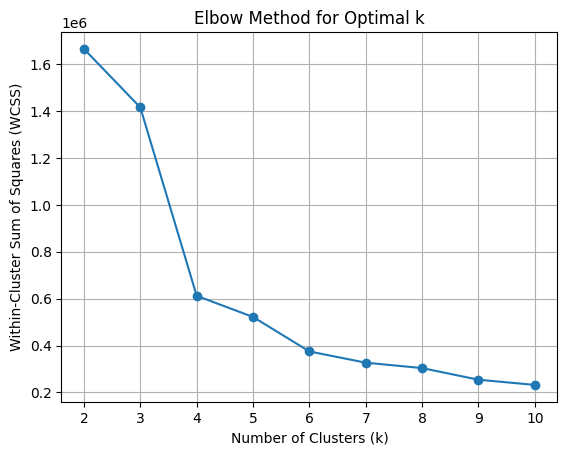

In [29]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
import numpy as np
import matplotlib.pyplot as plt

# Feature Engineering Pipeline
# Select features for clustering
feature_cols = ["Recency", "frequency", "monetory"]

# Assemble features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Scale features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

# Elbow Method to determine optimal number of clusters
wcss_values = []
for k in range(2, 11):
    kmeans = KMeans(featuresCol="scaled_features", predictionCol="clusters", k=k, seed=42)
    pipeline = Pipeline(stages=[assembler, scaler, kmeans])
    model = pipeline.fit(df_merged)
    wcss_values.append(model.stages[-1].summary.trainingCost)

# Plot the elbow curve
plt.plot(range(2, 11), wcss_values, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


In the above graph, we can observe drop at k=4.
So by elbow method, we choose K-means clusters as 4.

+--------------------+-------+---------+--------+--------+
|             user_id|Recency|frequency|monetory|clusters|
+--------------------+-------+---------+--------+--------+
|1.515915625450899...|      6|        1|  416.64|       1|
|1.515915625450899...|      7|        1|  416.64|       1|
|1.515915625450899...|      5|        1|  416.64|       0|
|1.515915625450899...|      4|        1|  416.64|       0|
|1.515915625450899...|     10|        1|  416.64|       1|
|1.515915625450899...|      9|        1|  416.64|       1|
|1.515915625450899...|      8|        1|  416.64|       1|
|1.515915625450899...|      3|        1|  416.64|       0|
|1.515915625450899...|      2|        1|  416.64|       0|
|1.515915625450899...|      1|        1|  416.64|       0|
|1.515915625450899...|      0|        1|  416.64|       0|
|1.515915625447780...|      6|        2|   18.51|       1|
|1.515915625447780...|      7|        2|   18.51|       1|
|1.515915625447780...|      5|        2|   18.51|       

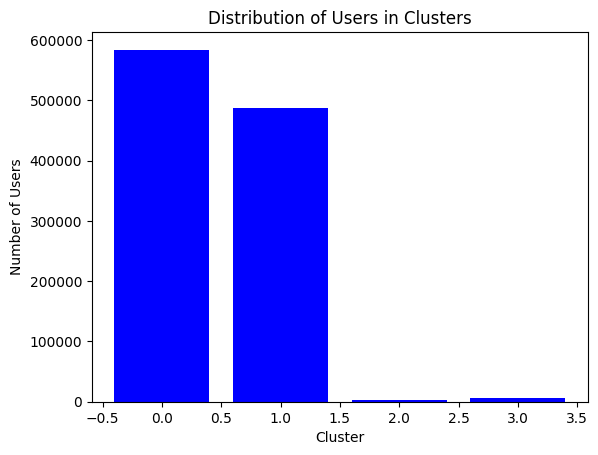

In [30]:
#  KMeans Clustering with k=4

kmeans = KMeans(featuresCol="scaled_features", predictionCol="clusters", k=4, seed=42)

# Creating the pipeline including the assembler, scaler, and kmeans
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# Fit the pipeline to the data
model = pipeline.fit(df_merged)

# Apply the model to the data
clustered_df = model.transform(df_merged)

# Show the DataFrame with added clusters column
clustered_df.select("user_id","Recency", "frequency", "monetory", "clusters").show()

cluster_counts = clustered_df.groupBy("clusters").count().orderBy("clusters")
cluster_counts_pd = cluster_counts.toPandas()

# Plot bar graph
plt.bar(cluster_counts_pd["clusters"], cluster_counts_pd["count"], color='blue')
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.title("Distribution of Users in Clusters")
plt.show()


##Cluster Analysis

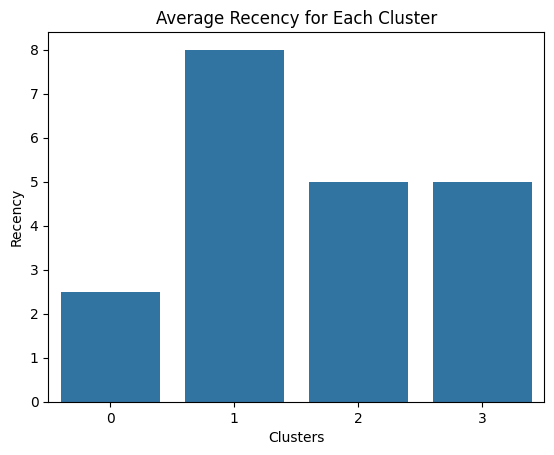

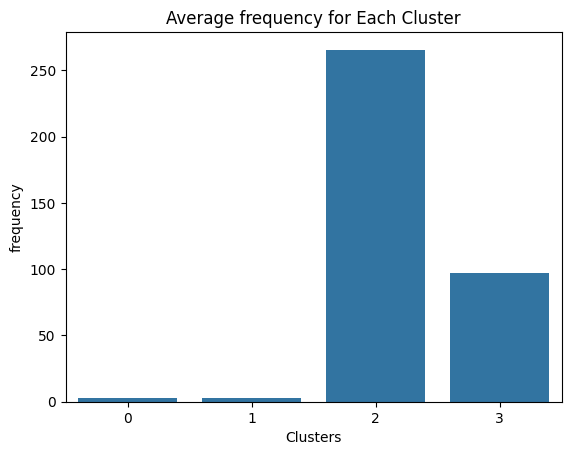

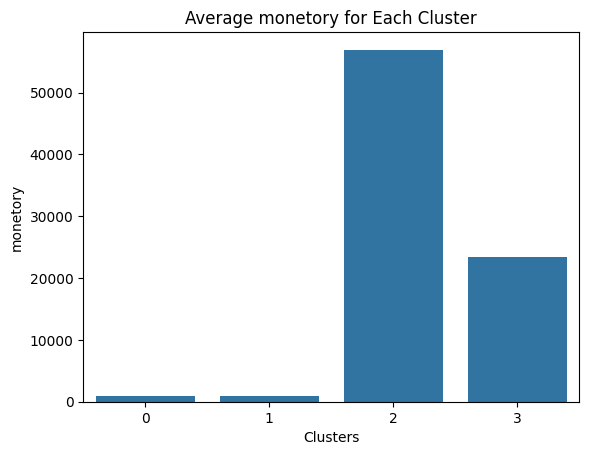

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualizing results
preds = clustered_df.select('Recency', 'frequency', 'monetory', 'clusters')
preds_pd = preds.toPandas()
avg_df = preds_pd.groupby(['clusters'], as_index=False).mean()

# Plot bar graphs for each feature against the clusters
features = ['Recency', 'frequency', 'monetory']
for feature in features:
    sns.barplot(x='clusters', y=feature, data=avg_df)
    plt.xlabel('Clusters')
    plt.ylabel(feature)
    plt.title(f'Average {feature} for Each Cluster')
    plt.show()


In [32]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

# Features
feature_cols = ["Recency", "frequency", "monetory"]

# Pipeline stages
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
kmeans = KMeans(featuresCol="scaled_features", k=4, seed=42)

pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# Train model
model = pipeline.fit(df_merged)

# Predict clusters
predictions = model.transform(df_merged)

# Final dataset
final_df = predictions.select(
    "user_id",
    "Recency",
    "frequency",
    "monetory",
    col("prediction").alias("cluster")
)

# Save file for Streamlit
final_df.toPandas().to_csv("final_rfm_clusters.csv", index=False)

**Cluster 0: Low Potential Customers**
- Description: Customers in this segment display medium recency (not recent purchases), low frequency (rarely shop on the platform), and low monetary value (low spending).
- Interpretation: These customers are not very engaged with the platform and are unlikely to make frequent or high-value purchases.
- Strategy:
  - Targeted promotions: Offer discounts or promotions to encourage repeat purchases.
  - Personalized recommendations: Use personalized recommendations to suggest relevant products based on their past purchases or browsing behavior.
  - Engage through marketing: Send targeted marketing campaigns to re-engage these customers and remind them of the benefits of shopping on the platform.

**Cluster 1: New Customers**
- Description: Customers in this cluster display high recency (recently made purchases) but haven't been seen visiting the platform often.
- Interpretation: These customers are new to the platform and may still be exploring products or services.
- Strategy:
  - Welcome offers: Provide special offers or discounts to welcome new customers and encourage them to make their first purchase.
  - Onboarding assistance: Offer guidance or assistance to help new customers navigate the platform and discover products of interest.
  - Engagement campaigns: Send targeted emails or notifications to keep new customers engaged and informed about new arrivals or promotions.

**Cluster 2: High-Value Customers**
- Description: Customers in this segment display respectable recency (recent purchases) with high frequency (frequent purchases) and high monetary values (high spending).
- Interpretation: These customers are valuable to the business as they make frequent purchases and spend a significant amount of money.
- Strategy:
  - VIP treatment: Offer exclusive benefits or rewards to recognize and appreciate these high-value customers.
  - Personalized service: Provide personalized customer service and assistance to enhance their shopping experience.
  - Recommend complementary or higher-value products to encourage additional purchases and increase average order value.

**Cluster 3: Average Customers**
- Description: Customers in this segment display medium recency, frequency, and monetary values.
- Interpretation: These customers are moderately engaged with the platform and make purchases at a moderate frequency and spending level.
- Strategy:
  - Loyalty programs: Offer loyalty programs or rewards to encourage repeat purchases and foster customer loyalty.
  - Targeted promotions: Provide targeted promotions or discounts based on their past purchase history to incentivize future purchases.
  - Customer feedback: Solicit feedback from these customers to understand their preferences and improve the overall shopping experience.